# Inteligência Artificial em Jogos 25/26
## Avaliação e Comparação de Performance (Ponto 5)

Neste notebook, vamos carregar os modelos vencedores (Genomas) de ambas as abordagens (Radares e Waypoints) e as respetivas estatísticas. O objetivo é:
1. Comparar as métricas finais (Melhor Fitness, Gerações até à vitória, Tempo de Treino).
2. Visualizar graficamente a topologia das redes neuronais evoluídas.

In [ ]:
import pickle
import neat
import matplotlib.pyplot as plt
import os

# Tenta importar o script visualize (fornecido nos labs/livro) para desenhar as redes
try:
    import os
    # Força o Python a encontrar o motor do Graphviz no teu PC
    os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

    import visualize
    HAS_VISUALIZE = True
except ImportError:
    HAS_VISUALIZE = False
    print("Aviso: O ficheiro visualize.py não foi encontrado na pasta. Os gráficos das redes não serão gerados.")

# 1. Carregar dados dos Radares
try:
    with open('models/stats_radares.pkl', 'rb') as f:
        stats_rad = pickle.load(f)
    with open('models/winner_radares.pkl', 'rb') as f:
        winner_rad = pickle.load(f)
    print("Dados dos Radares carregados com sucesso!")
except FileNotFoundError:
    print("Ficheiros dos Radares não encontrados.")

# 2. Carregar dados dos Waypoints
try:
    with open('models/stats_waypoints.pkl', 'rb') as f:
        stats_way = pickle.load(f)
    with open('models/winner_waypoints.pkl', 'rb') as f:
        winner_way = pickle.load(f)
    print("Dados dos Waypoints carregados com sucesso!")
except FileNotFoundError:
    print("Ficheiros dos Waypoints não encontrados.")

✅ Dados dos Radares carregados com sucesso!
✅ Dados dos Waypoints carregados com sucesso!


### Comparação Direta (Estatísticas de Treino)
Vamos colocar lado a lado o desempenho do treino para perceber qual das abordagens aprendeu a conduzir mais depressa e de forma mais eficiente.

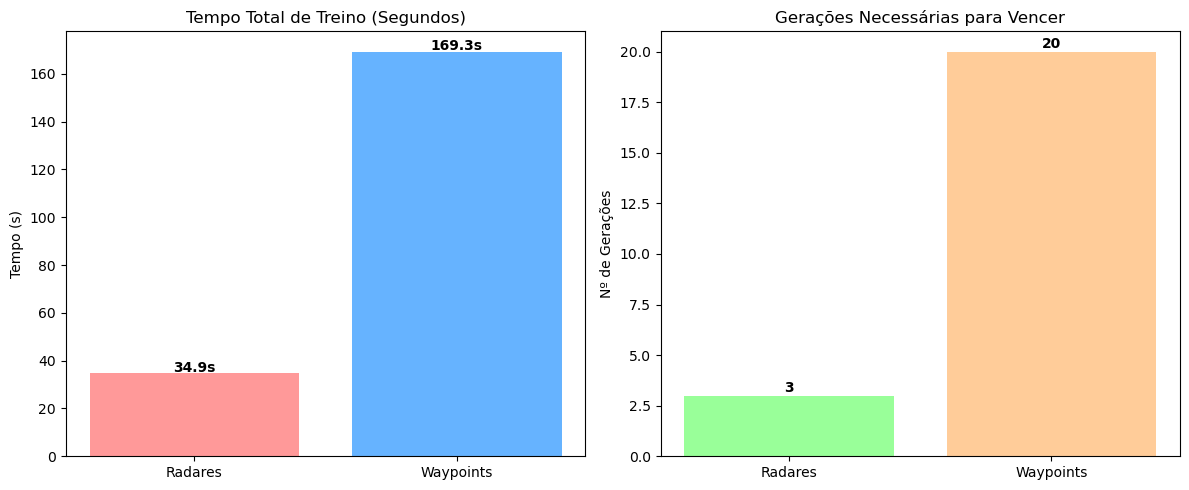

--- ANÁLISE DOS MODELOS VENCEDORES ---
RADARES   | Tamanho da Rede: 2 Nós, 10 Conexões ativas
WAYPOINTS | Tamanho da Rede: 2 Nós, 4 Conexões ativas


In [5]:
# Preparar os dados para os gráficos
labels = ['Radares', 'Waypoints']
tempos = [stats_rad.get('tempo_total', 0), stats_way.get('tempo_total', 0)]
geracoes = [stats_rad.get('melhor_geracao', 0), stats_way.get('melhor_geracao', 0)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Tempo Total de Treino
ax1.bar(labels, tempos, color=['#ff9999','#66b3ff'])
ax1.set_title('Tempo Total de Treino (Segundos)')
ax1.set_ylabel('Tempo (s)')
for i, v in enumerate(tempos):
    ax1.text(i, v + 0.5, f"{v:.1f}s", ha='center', fontweight='bold')

# Gráfico 2: Número de Gerações até à Vitória
ax2.bar(labels, geracoes, color=['#99ff99','#ffcc99'])
ax2.set_title('Gerações Necessárias para Vencer')
ax2.set_ylabel('Nº de Gerações')
for i, v in enumerate(geracoes):
    ax2.text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("--- ANÁLISE DOS MODELOS VENCEDORES ---")
print(f"RADARES   | Tamanho da Rede: {len(winner_rad.nodes)} Nós, {len(winner_rad.connections)} Conexões ativas")
print(f"WAYPOINTS | Tamanho da Rede: {len(winner_way.nodes)} Nós, {len(winner_way.connections)} Conexões ativas")

### Visualização das Topologias (Redes Neuronais)
Uma das vantagens do algoritmo NEAT é evoluir não só os pesos (como numa rede neuronal fixa), mas também a topologia da rede (adicionando nós e ligações complexas de forma dinâmica). 

Abaixo geramos os diagramas das redes vencedoras para incluirmos no relatório final.

In [ ]:
if HAS_VISUALIZE:
    config_rad = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                             neat.DefaultSpeciesSet, neat.DefaultStagnation,
                             stats_rad['config'])
    
    config_way = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                             neat.DefaultSpeciesSet, neat.DefaultStagnation,
                             stats_way['config'])

    node_names_rad = {-1: 'R_Esq (-60)', -2: 'R_Esq_C (-30)', -3: 'R_Frente (0)', 
                      -4: 'R_Dir_C (+30)', -5: 'R_Dir (+60)', 0: 'Acelerar', 1: 'Virar'}
                      
    node_names_way = {-1: 'Distância', -2: 'Ângulo', 0: 'Acelerar', 1: 'Virar'}

    print("A desenhar a Rede dos Radares...")
    visualize.draw_net(config_rad, winner_rad, True, node_names=node_names_rad, filename="rede_radares.gv")
    
    print("A desenhar a Rede dos Waypoints...")
    visualize.draw_net(config_way, winner_way, True, node_names=node_names_way, filename="rede_waypoints.gv")
    
    print("Gráficos gerados com sucesso! Podes encontrá-los na tua pasta como 'rede_radares.gv.svg' e 'rede_waypoints.gv.svg'.")
else:
    print("Para gerar os diagramas das redes, certifica-te que o 'visualize.py' e o Graphviz estão instalados e na mesma pasta.")

A desenhar a Rede dos Radares...
A desenhar a Rede dos Waypoints...
Gráficos gerados com sucesso! Podes encontrá-los na tua pasta como 'rede_radares.gv.svg' e 'rede_waypoints.gv.svg'.


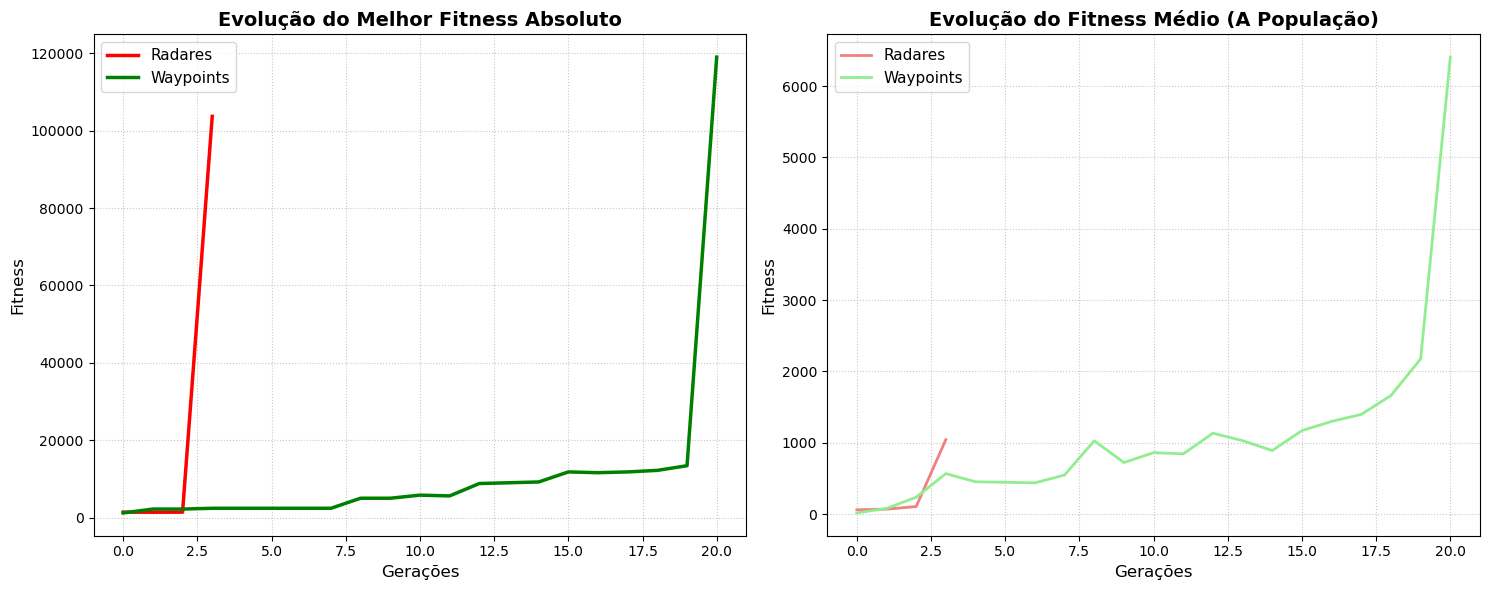

In [ ]:
import matplotlib.pyplot as plt

historico_melhor_rad = stats_rad.get('historico_melhor', [])
historico_media_rad = stats_rad.get('historico_media', [])

historico_melhor_way = stats_way.get('historico_melhor', [])
historico_media_way = stats_way.get('historico_media', [])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(historico_melhor_rad, label="Radares", color="red", linewidth=2.5)
ax1.plot(historico_melhor_way, label="Waypoints", color="green", linewidth=2.5)
ax1.set_title("Evolução do Melhor Fitness Absoluto", fontsize=14, fontweight='bold')
ax1.set_xlabel("Gerações", fontsize=12)
ax1.set_ylabel("Fitness", fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.7)

ax2.plot(historico_media_rad, label="Radares", color="lightcoral", linewidth=2)
ax2.plot(historico_media_way, label="Waypoints", color="lightgreen", linewidth=2)
ax2.set_title("Evolução do Fitness Médio (A População)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Gerações", fontsize=12)
ax2.set_ylabel("Fitness", fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()